In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import scipy.stats as st
from uncertainties import ufloat
import uncertainties
from uncertainties.umath import *
pd.set_option('future.no_silent_downcasting', True)
from statannotations.Annotator import Annotator


In [3]:
figure_folder = Path('../../Figures/interactions')
figure_folder.mkdir(exist_ok=True)

In [4]:
folder = Path('../../data/3_interactions/')
df = pd.read_csv(folder / 'all_interactions_cfus.csv')

In [5]:
species_palette = {
    'At': 'C2',
    'Ct': 'C1',
    'Oa': 'C3',
    'Ml': 'C0',
    
}

# Quantify interactions

In [6]:
df.reset_index(drop=True)
df['Is coculture'] = ['+' in x for x in df['Inoculated species']]
 

In [7]:
df.Medium.unique()

array(['Ml_mannose', 'Ct_isoleucine', 'Oa_mannose', 'No CS', 'At_mannose',
       'M9_mannose', 'M9_mannose+thiamine',
       'M9_mannose+thiamine+biotin+cysteine+proline', 'M9_isoleucine',
       'M9_isoleucine+thiamine+biotin+cysteine+proline',
       'M9_isoleucine+thiamine', 'At_malate', 'Ct_malate', 'Ml_malate',
       'Oa_malate', 'M9_malate', 'M9_malate+thiamine',
       'M9_malate+thiamine+biotin+cysteine+proline'], dtype=object)

In [8]:

four_species = ['At', 'Ct', 'Ml', 'Oa']
interactions = []
for medium in df.Medium.unique():
    if medium == 'No CS':
        continue
    dfm = df.loc[df.Medium==medium]
    dfm_co = dfm.loc[dfm['Is coculture']==True]
    # dfm_mono = dfm.loc[dfm['Is coculture']!=True]
    coculture_pairs = dfm_co['Inoculated species'].unique()
    for pair in coculture_pairs:
        s1,s2 = pair.split('+')
        # Interaction of 2 on 1
        # Log response ratio
        s1_growth_in_mono = dfm.loc[(dfm['Inoculated species']==s1)&(dfm.Species==s1), 'CFUs/mL'].dropna()
        s1_growth_in_co   = dfm.loc[(dfm['Inoculated species']==pair)&(dfm.Species==s1), 'CFUs/mL'].dropna()
        s1_mono = ufloat(s1_growth_in_mono.mean(), s1_growth_in_mono.std())
        s1_co = ufloat(s1_growth_in_co.mean(), s1_growth_in_co.std())
        
        lrr_s1 = log10(s1_co/s1_mono)
        ttest_res1 = st.ttest_ind(s1_growth_in_mono, s1_growth_in_co)
        
        s2_growth_in_mono = dfm.loc[(dfm['Inoculated species']==s2)&(dfm.Species==s2), 'CFUs/mL'].dropna()
        s2_growth_in_co   = dfm.loc[(dfm['Inoculated species']==pair)&(dfm.Species==s2), 'CFUs/mL'].dropna()
        s2_mono = ufloat(s2_growth_in_mono.mean(), s2_growth_in_mono.std())
        s2_co   = ufloat(s2_growth_in_co.mean(), s2_growth_in_co.std())
        
        lrr_s2 = log10(s2_co/s2_mono)
        # lrr_s2 = np.log10(s2_growth_in_co.mean()/s2_growth_in_mono.mean())
        ttest_res2 = st.ttest_ind(s2_growth_in_mono, s2_growth_in_co)

        # rd_s1 = (s1_growth_in_co.mean()-s1_growth_in_mono.mean())/s2_growth_in_co.mean()
        # rd_s2 = (s2_growth_in_co.mean()-s2_growth_in_mono.mean())/s1_growth_in_co.mean()

        interactions.append([s1, s2, medium, lrr_s1.nominal_value, lrr_s1.std_dev, ttest_res1.pvalue])
        interactions.append([s2, s1, medium, lrr_s2.nominal_value, lrr_s2.std_dev, ttest_res2.pvalue])
interactions_df = pd.DataFrame(interactions, columns = ['Focal species', 'Partner species', 'Medium', 
                                                                   'log10 ratio','log10 ratio std', 'T-test pvalue'])


In [9]:
from statsmodels.stats.multitest import multipletests

# Perform multiple test correction using the Benjamini-Hochberg procedure
pvalues = interactions_df['T-test pvalue']
corrected_pvalues = multipletests(pvalues, method='fdr_bh')[1]  # [1] gives the adjusted p-values

# Add the corrected p-values to the DataFrame
interactions_df['Corrected pvalue'] = corrected_pvalues

In [10]:
interactions_df['log10 pval'] = np.log10(interactions_df['T-test pvalue'])
interactions_df['log10 adj. pval'] = np.log10(interactions_df['Corrected pvalue'])

In [11]:
interactions_df.head()

,Focal species,Partner species,Medium,log10 ratio,log10 ratio std,T-test pvalue,Corrected pvalue,log10 pval,log10 adj. pval
0,At,Ct,Ml_mannose,-0.130848,0.149839,0.146230,0.237933,-0.834964,-0.623545
1,Ct,At,Ml_mannose,-0.070200,0.192876,0.419410,0.509663,-0.377361,-0.292717
2,At,Oa,Ml_mannose,-0.230742,0.043686,0.000121,0.000892,-3.918152,-3.049824
3,Oa,At,Ml_mannose,-0.282281,0.189848,0.043636,0.095207,-1.360151,-1.021333
4,Ct,Oa,Ml_mannose,-0.121352,0.135099,0.157224,0.251558,-0.803482,-0.599362


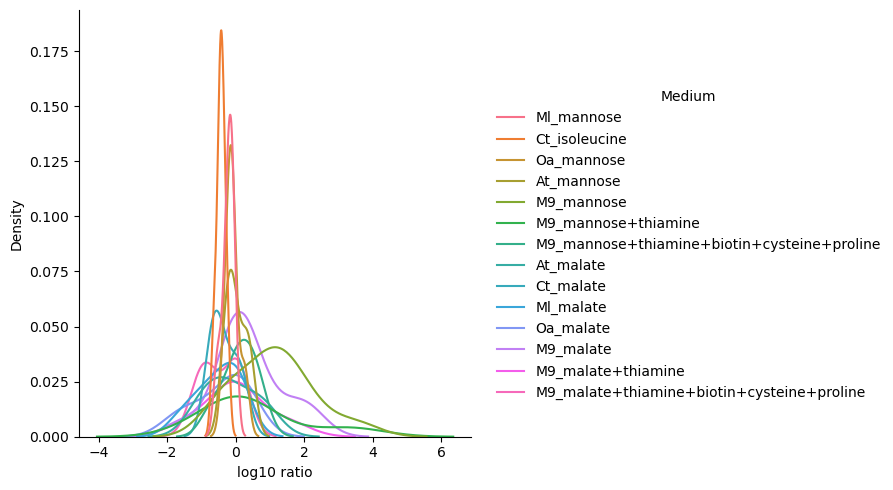

In [12]:
ax = sns.displot(data = interactions_df, x = 'log10 ratio', hue = 'Medium', kind = 'kde')


In [13]:
interactions_df

,Focal species,Partner species,Medium,log10 ratio,log10 ratio std,T-test pvalue,Corrected pvalue,log10 pval,log10 adj. pval
0,At,Ct,Ml_mannose,-0.130848,0.149839,0.146230,0.237933,-0.834964,-0.623545
1,Ct,At,Ml_mannose,-0.070200,0.192876,0.419410,0.509663,-0.377361,-0.292717
2,At,Oa,Ml_mannose,-0.230742,0.043686,0.000121,0.000892,-3.918152,-3.049824
3,Oa,At,Ml_mannose,-0.282281,0.189848,0.043636,0.095207,-1.360151,-1.021333
4,Ct,Oa,Ml_mannose,-0.121352,0.135099,0.157224,0.251558,-0.803482,-0.599362
...,...,...,...,...,...,...,...,...,...
91,Ml,At,M9_malate+thiamine+biotin+cysteine+proline,-0.888026,0.230853,0.003270,0.013080,-2.485463,-1.883403
92,Ct,Ml,M9_malate+thiamine+biotin+cysteine+proline,0.038708,0.150593,0.625752,0.674969,-0.203597,-0.170716
93,Ml,Ct,M9_malate+thiamine+biotin+cysteine+proline,-1.069081,0.267553,0.002531,0.011045,-2.596692,-1.956844
94,Ml,Oa,M9_malate+thiamine+biotin+cysteine+proline,-0.791116,0.167765,0.003785,0.014534,-2.421943,-1.837612


In [14]:
interactions_df['Fresh'] = ['Fresh' if x.split('_')[0]=='M9' else 'Spent' for x in interactions_df.Medium]

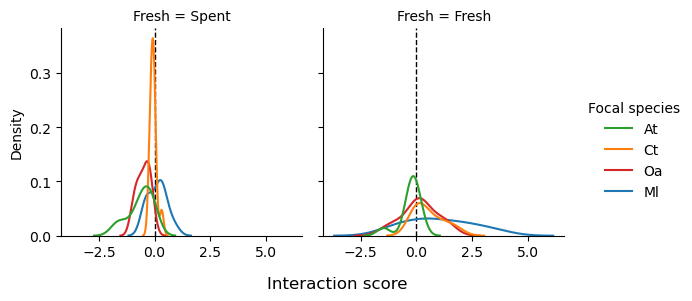

In [15]:
g = sns.displot(data = interactions_df, x = 'log10 ratio', hue = 'Focal species', palette=species_palette, fill = False, 
                kind = 'kde', col='Fresh', aspect=1, height=3)#, alpha = 0.5)
for ax in g.axes.flat:
     ax.axvline(0, ls = '--', c = 'k', zorder=0, lw=1)
     ax.set_xlabel('')
g.fig.supxlabel('Interaction score')
plt.savefig(figure_folder / f'interaction_distribution_species.pdf')



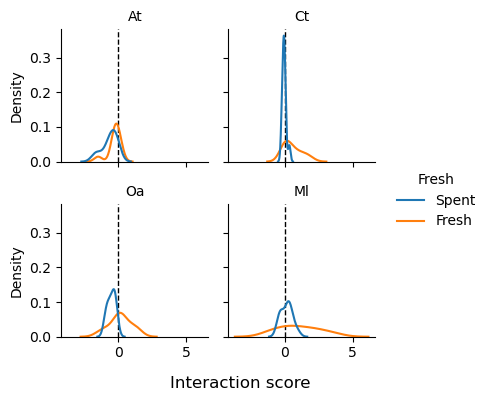

In [16]:
g = sns.displot(data = interactions_df, x = 'log10 ratio', hue = 'Fresh', fill = False, 
                kind = 'kde', col='Focal species', aspect=1, height=2, col_wrap=2)#, alpha = 0.5)
for ax in g.axes.flat:
     ax.axvline(0, ls = '--', c = 'k', zorder=0, lw=1)
     ax.set_xlabel('')
g.fig.supxlabel('Interaction score')
g.set_titles("{col_name}")
plt.savefig(figure_folder / f'interaction_distribution_species_fresh_spent.pdf')

In [17]:
interactions_df.groupby(['Focal species', 'Fresh']).agg({'log10 ratio': ['mean', 'std']}).reset_index().rename(columns = {'mean': 'Mean', 'std': 'Std'})

Focal species  Fresh log10 ratio          
                              Mean       Std
0            At  Fresh   -0.263211  0.461146
1            At  Spent   -0.634563  0.550048
2            Ct  Fresh    0.550945  0.660144
3            Ct  Spent   -0.058949  0.145235
4            Ml  Fresh    1.009850  1.486216
5            Ml  Spent    0.114141  0.412144
6            Oa  Fresh    0.143859  0.801051
7            Oa  Spent   -0.506000  0.294736

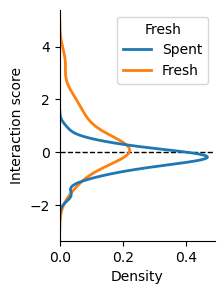

In [18]:
fig, ax = plt.subplots(figsize = (2, 3))
ax = sns.kdeplot(data = interactions_df, y = 'log10 ratio', hue = 'Fresh', lw=2)
ax.axhline(0, ls = '--', c = 'k', zorder=0, lw = 1)
sns.despine()
ax.set_ylabel('Interaction score')
plt.savefig(figure_folder / f'interaction_distribution_fresh_spent.pdf')

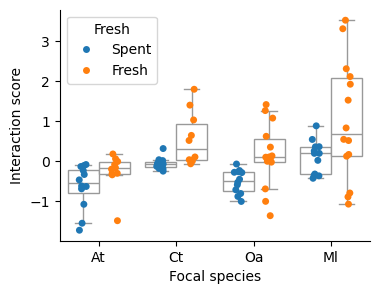

In [19]:
fig, ax = plt.subplots(1, figsize=(4,3))
ax = sns.boxplot(data = interactions_df, y = 'log10 ratio', x = 'Focal species', color = 'w', fliersize=0, 
                 hue = 'Fresh', palette={'Spent':'w', 'Fresh':'w'}, legend=False)
sns.stripplot(data = interactions_df, y = 'log10 ratio', x = 'Focal species', hue = 'Fresh',dodge=True)# palette=species_palette)
sns.despine()
ax.set_ylabel('Interaction score')
plt.savefig(figure_folder / f'interaction_boxplots_focal_species.pdf', bbox_inches='tight')


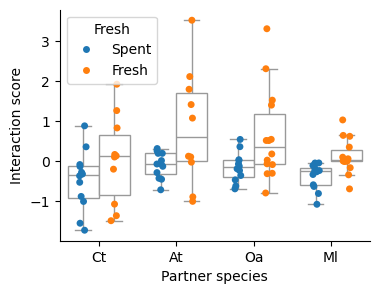

In [20]:
fig, ax = plt.subplots(1, figsize=(4,3))
ax = sns.boxplot(data = interactions_df, y = 'log10 ratio', x = 'Partner species', color = 'w', fliersize=0, 
                 hue = 'Fresh', palette={'Spent':'w', 'Fresh':'w'}, legend=False)
sns.stripplot(data = interactions_df, y = 'log10 ratio', x = 'Partner species', hue = 'Fresh',dodge=True)# palette=species_palette)
sns.despine()
ax.set_ylabel('Interaction score')
plt.savefig(figure_folder / f'interaction_boxplots_partner_species.pdf', bbox_inches='tight')




In [21]:

groups = [group['log10 ratio'].values for name, group in interactions_df.groupby('Fresh')]

# Perform one-way ANOVA
f_stat, p_value = st.kruskal(*groups)

# Print the results
print(f"F-statistic: {f_stat}")
print(f"P-value: {p_value}")

F-statistic: 15.253919673539542
P-value: 9.398151256311726e-05


Spent: t-statistic = -3.89430192976858, p-value = 0.0003101768220518331, mean -0.271
Fresh: t-statistic = 2.5709300657537755, p-value = 0.013368794310377338, mean 0.396


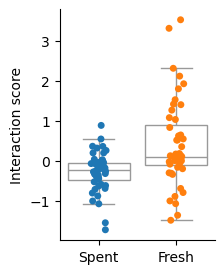

In [23]:
fig, ax = plt.subplots(1, figsize=(2,3))
ax = sns.boxplot(data = interactions_df, y = 'log10 ratio', x = 'Fresh', color = 'w', fliersize=0, 
                 hue = 'Fresh', palette={'Spent':'w', 'Fresh':'w'}, legend=False)
sns.stripplot(data = interactions_df, y = 'log10 ratio', x = 'Fresh', hue = 'Fresh')# palette=species_palette)
sns.despine()
ax.set_ylabel('Interaction score')
plt.xlabel('')

# pairs = [['Spent', 'Fresh']]

# annotator = Annotator(
#     ax, pairs, data=interactions_df, y = 'log10 ratio', x = 'Fresh' #orient="h" 
# )
# # plt.ylim(0,2)
# annotator.configure(text_format="star", loc="inside",
#     hide_non_significant=True, alpha=0.05)
# annotator.set_pvalues_and_annotate([p_value])

# Perform a one-sample t-test for each group
spent_data = interactions_df.loc[interactions_df['Fresh'] == 'Spent', 'log10 ratio']
fresh_data = interactions_df.loc[interactions_df['Fresh'] == 'Fresh', 'log10 ratio']

# Test if the mean of 'Spent' is different from 0
t_stat_spent, p_value_spent = st.ttest_1samp(spent_data, 0)

# Test if the mean of 'Fresh' is different from 0
t_stat_fresh, p_value_fresh = st.ttest_1samp(fresh_data, 0)

# Print the results
print(f"Spent: t-statistic = {t_stat_spent}, p-value = {p_value_spent}, mean {spent_data.mean():.3f}")
print(f"Fresh: t-statistic = {t_stat_fresh}, p-value = {p_value_fresh}, mean {fresh_data.mean():.3f}")
plt.savefig(figure_folder / f'interaction_boxplot_fresh_spent.pdf', bbox_inches='tight')
plt.savefig(figure_folder / f'interaction_boxplot_fresh_spent.png', bbox_inches='tight', dpi=300)

In [24]:
interactions_df['Significance'] = interactions_df['Corrected pvalue']<0.05
interactions_df.groupby('Fresh').agg({'Significance':'sum'})

,Significance
Fresh,
Fresh,23
Spent,7


In [25]:
interactions_df['abs log10 ratio'] = np.abs(interactions_df['log10 ratio'])
interactions_df[['abs log10 ratio', 'Fresh']].groupby('Fresh').agg(['mean', 'median', 'std'])

abs log10 ratio                    
                 mean    median       std
Fresh                                    
Fresh        0.761269  0.518039  0.842620
Spent        0.404815  0.299955  0.375321

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_87007/621205132.py:5: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


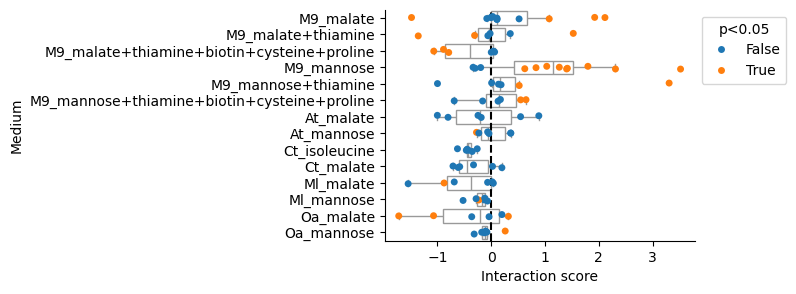

In [26]:
fig, ax = plt.subplots(1, figsize = (4,3))
sns.stripplot(data = interactions_df.sort_values(by=['Fresh','Medium']), x = 'log10 ratio', y = 'Medium', hue = 'Significance', ax=ax)# palette='copper', 
sns.boxplot(data = interactions_df, x = 'log10 ratio', y = 'Medium', color = 'w', fliersize=0)
ax.axvline(0, ls = '--', c = 'k', zorder = 2)
plt.tight_layout()
sns.move_legend(ax, title='p<0.05', loc='upper left', bbox_to_anchor=(1, 1))
sns.despine()
plt.xlabel('Interaction score')
plt.savefig(figure_folder/'Interactions_per_medium.pdf')

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_87007/2048964825.py:5: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


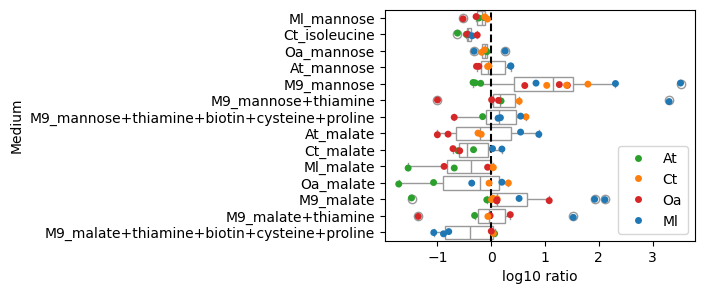

In [27]:
fig, ax = plt.subplots(1, figsize = (4,3))
sns.stripplot(data = interactions_df, x = 'log10 ratio', y = 'Medium', hue = 'Focal species', palette=species_palette, ax=ax)
sns.boxplot(data = interactions_df, x = 'log10 ratio', y = 'Medium', color = 'w')
ax.axvline(0, ls = '--', c = 'k', zorder = 2)
plt.tight_layout()
# plt.savefig('Interactions mannose.pdf')

In [28]:
interactions_df.loc[interactions_df.isna().any(axis=1)]

,Focal species,Partner species,Medium,log10 ratio,log10 ratio std,T-test pvalue,Corrected pvalue,log10 pval,log10 adj. pval,Fresh,Significance,abs log10 ratio
66,At,Ct,Oa_malate,-1.720159,NaN,4.123855e-07,0.000013,-6.384697,-4.879547,Spent,True,1.720159
68,At,Ml,Oa_malate,-1.073021,NaN,2.096199e-04,0.001437,-3.678568,-2.842424,Spent,True,1.073021


# Heatmaps


In [29]:
interactions_df['Significance annot'] = ''
for i, row in interactions_df.iterrows():
    if 0.01 < row['Corrected pvalue'] < 0.05:
        annot = '*'
    elif 0.001 < row['Corrected pvalue'] < 0.01:
        annot = '**'
    elif row['Corrected pvalue'] < 0.001:
        annot = '***'
    else:
        annot = ''
    interactions_df.at[i, 'Significance annot'] = annot
    

Ml_mannose
Ct_isoleucine
Oa_mannose
At_mannose
M9_mannose
M9_mannose+thiamine
M9_mannose+thiamine+biotin+cysteine+proline
At_malate
Ct_malate
Ml_malate
Oa_malate
M9_malate
M9_malate+thiamine
M9_malate+thiamine+biotin+cysteine+proline


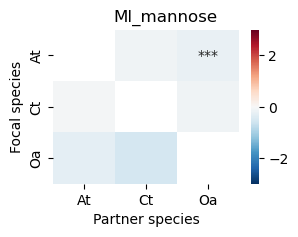

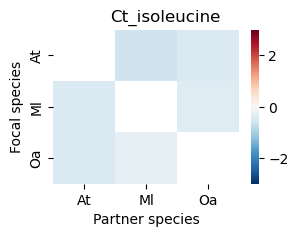

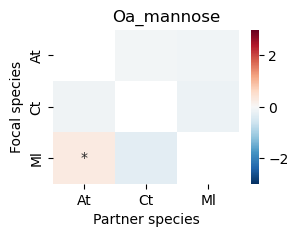

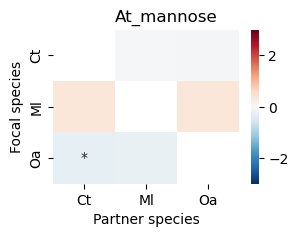

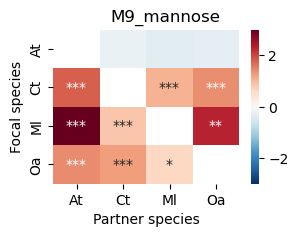

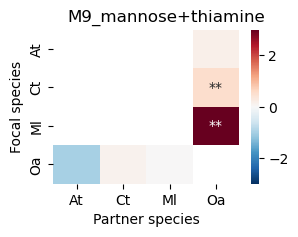

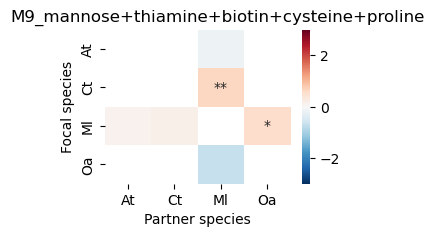

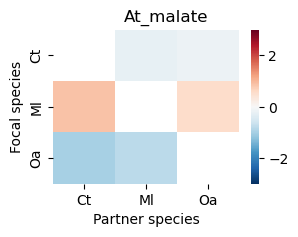

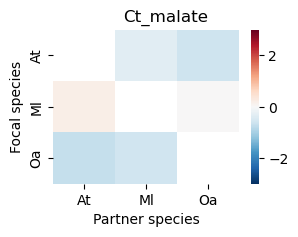

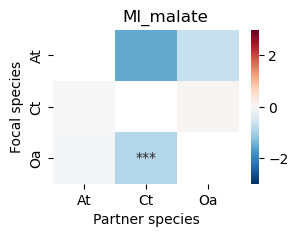

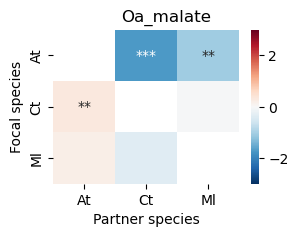

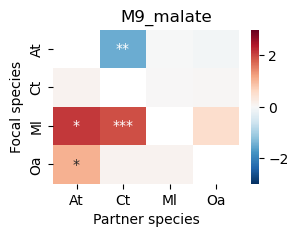

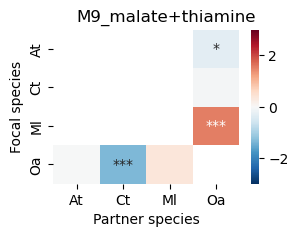

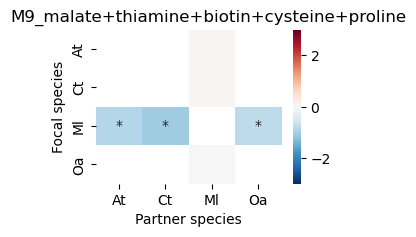

In [30]:
for medium in interactions_df.Medium.unique():
    print(medium)
    dfm = interactions_df.loc[interactions_df.Medium==medium]
    dfmp = dfm.pivot(columns = 'Partner species', index = 'Focal species')
    fig, ax = plt.subplots(1, figsize = (3,2))
    fig.suptitle(medium)
    sns.heatmap(dfmp['log10 ratio'], cmap = 'RdBu_r', ax = ax, vmin = -3, vmax = 3, annot = dfmp['Significance annot'], fmt = '')
    plt.savefig(figure_folder / f'interaction_heatmap_{medium}.pdf')

In [31]:
cfu_df = cfu_df_dict['spent_mannose2']
idx = cfu_df.Plate!=0
sns.catplot(data = cfu_df.loc[idx], y= 'Inoculated species', x = 'CFUs/mL', hue = 'Species', col = 'Medium', col_wrap=3,  kind = 'strip')#join=False removes lines between points, markers ensure points are dots, scale adjust the dots size
plt.xscale('log')
# plt.xlim(1e3, 1e11)
plt.show()

NameError: name 'cfu_df_dict' is not defined

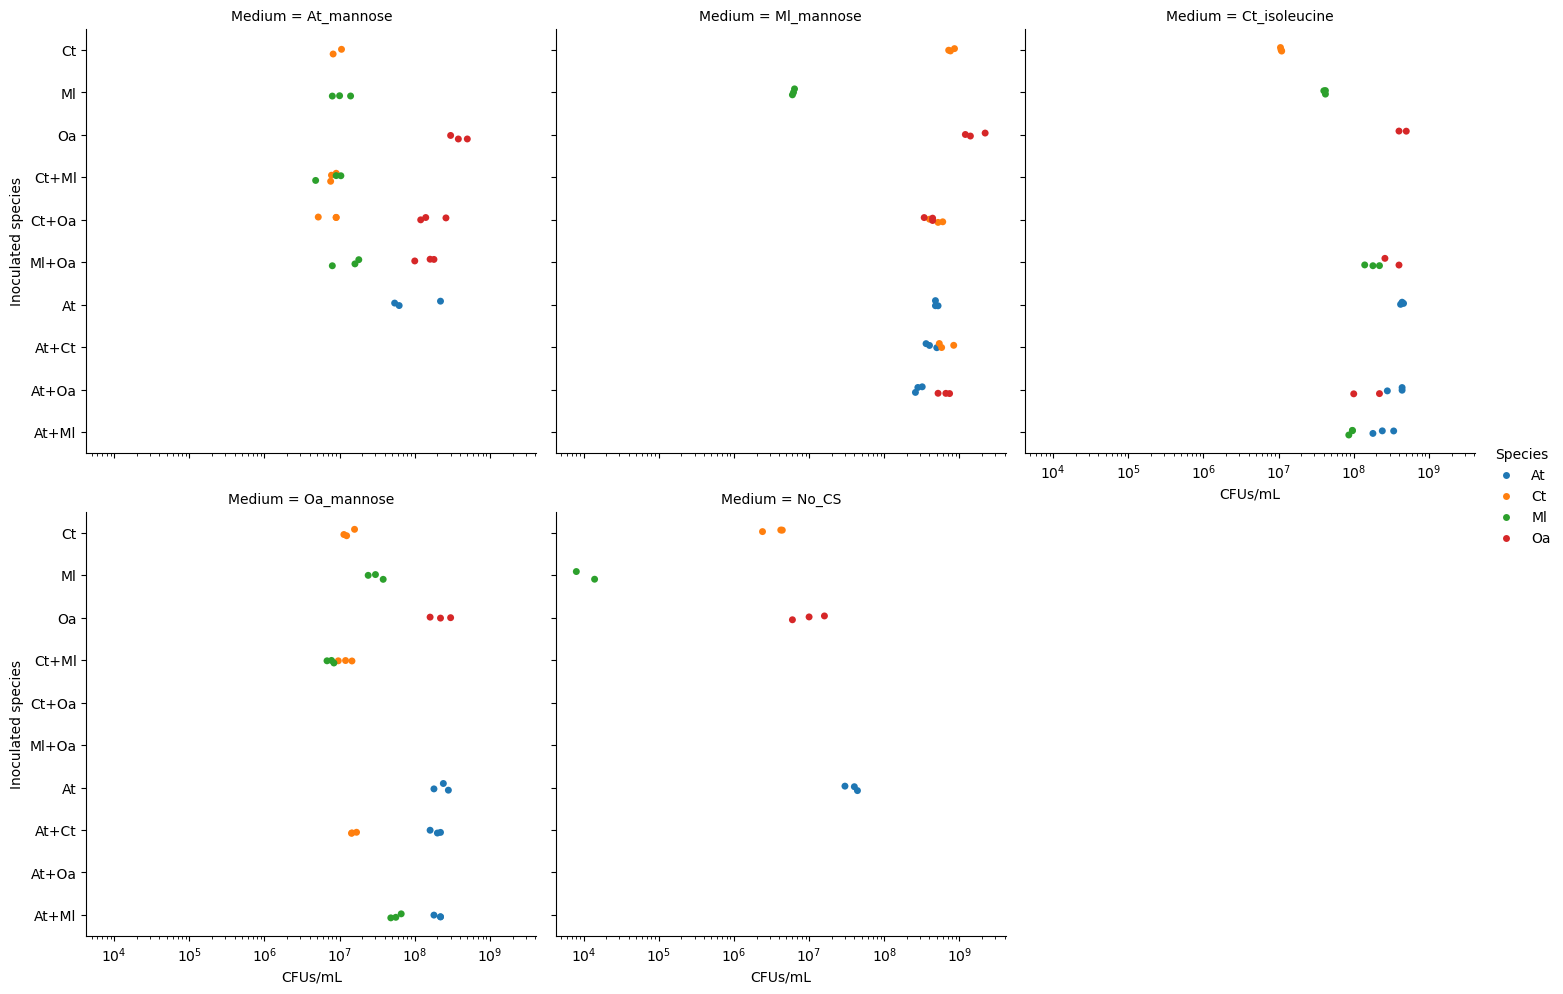

In [ ]:
cfu_df = cfu_df_dict['spent_mannose3']
idx = cfu_df.Plate!=0
sns.catplot(data = cfu_df.loc[idx], y= 'Inoculated species', x = 'CFUs/mL', hue = 'Species', col = 'Medium', col_wrap=3,  kind = 'strip')#join=False removes lines between points, markers ensure points are dots, scale adjust the dots size
plt.xscale('log')
# plt.xlim(1e3, 1e11)
plt.show()

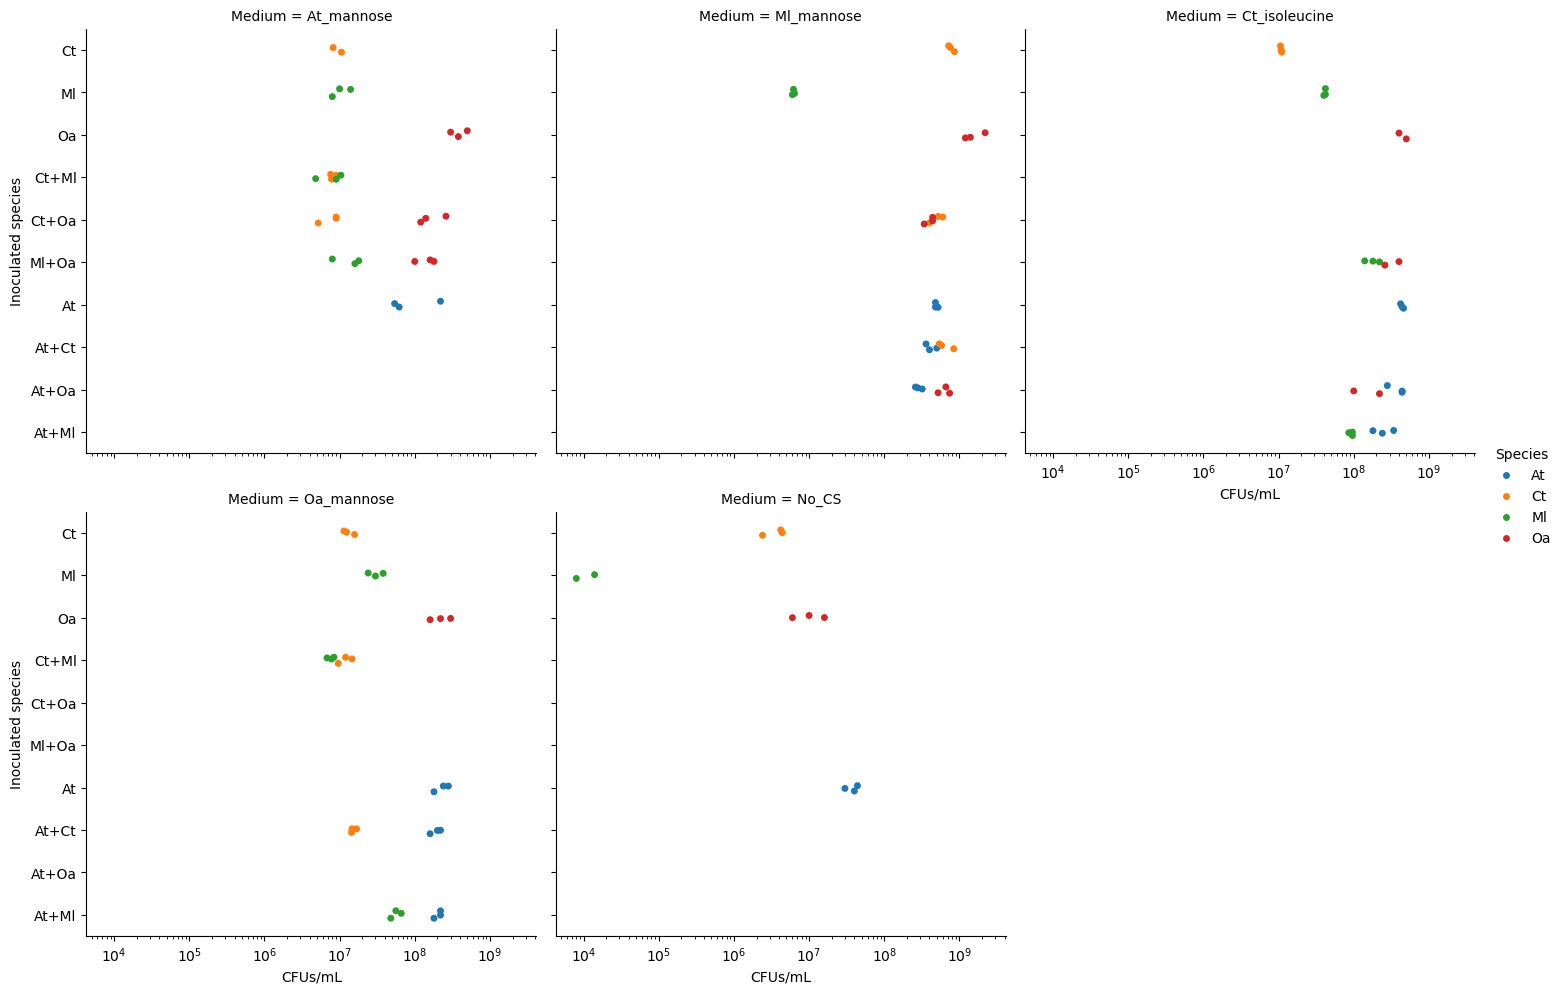

In [ ]:
idx = cfu_df.Plate!=0
sns.catplot(data = cfu_df.loc[idx], y= 'Inoculated species', x = 'CFUs/mL', hue = 'Species', col = 'Medium', col_wrap=3,  kind = 'strip')#join=False removes lines between points, markers ensure points are dots, scale adjust the dots size
plt.xscale('log')
# plt.xlim(1e3, 1e11)
plt.show()

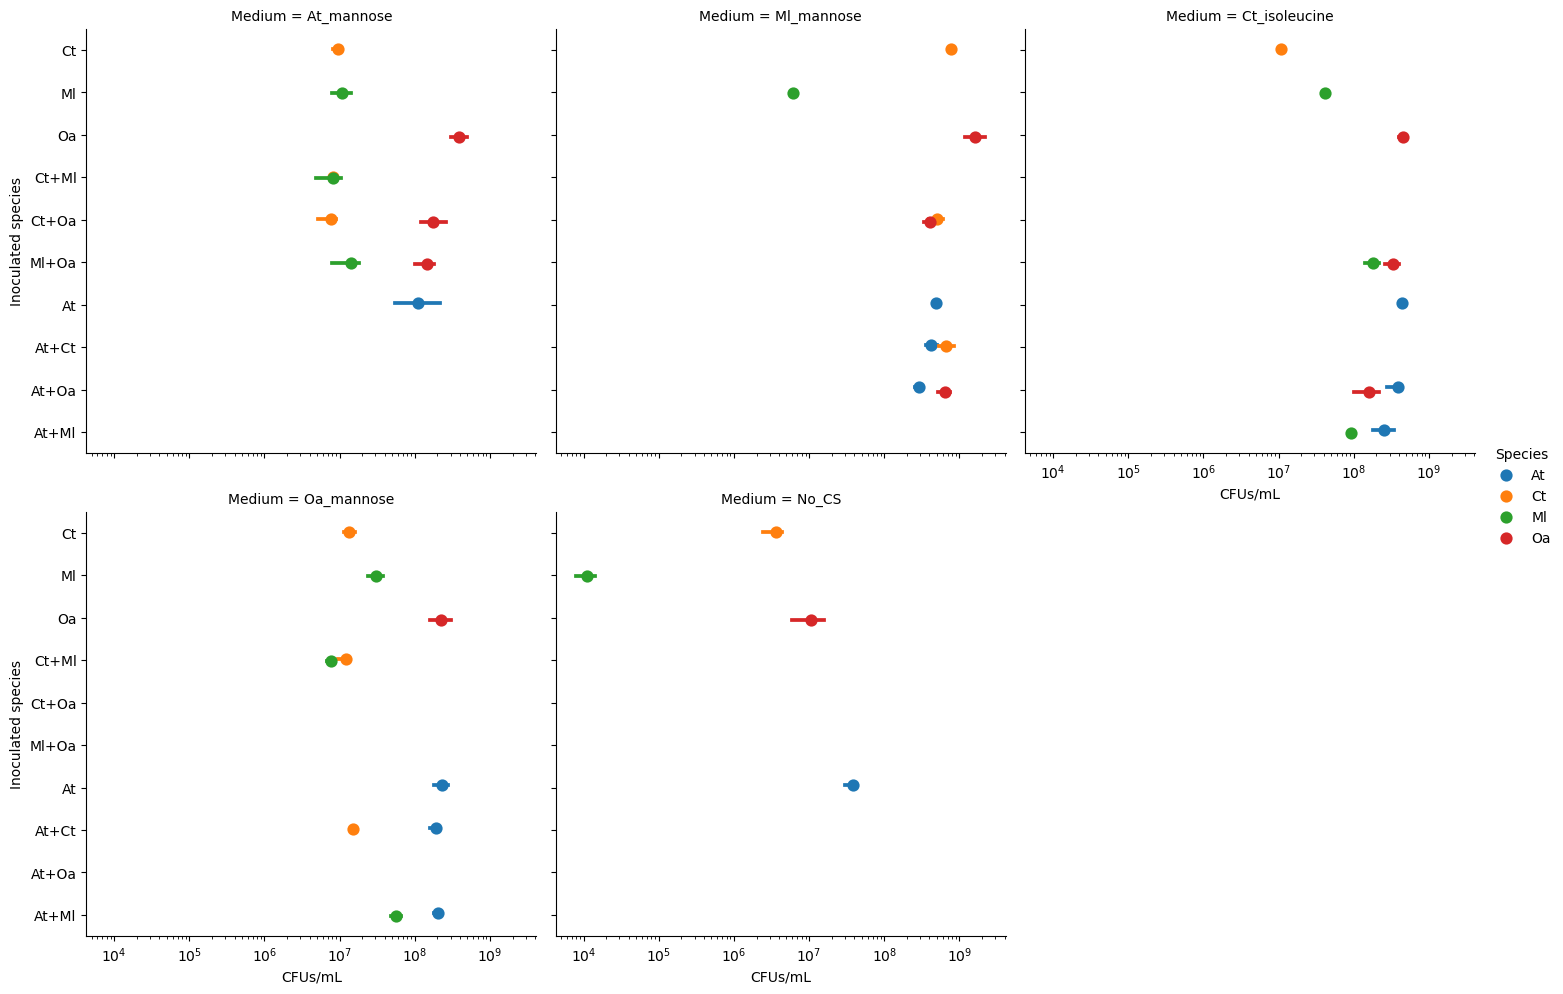

In [ ]:
idx = cfu_df.Plate!=0
sns.catplot(data = cfu_df.loc[idx], y= 'Inoculated species', x = 'CFUs/mL', hue = 'Species', col = 'Medium', col_wrap=3,  kind = 'point', dodge=True, markers="o", linestyle = 'None')#join=False removes lines between points, markers ensure points are dots, scale adjust the dots size
plt.xscale('log')
# plt.xlim(1e3, 1e11)
plt.show()

# Quantify interactions

In [ ]:
# Join spent mannose data
spent_mannose_cfu = pd.concat([cfu_df_dict['spent_mannose2'], cfu_df_dict['spent_mannose3']])
spent_mannose_cfu.reset_index(inplace=True, drop = True)

In [ ]:
spent_mannose_cfu.to_csv('cfus_spent_mannose.csv')

## Spent medium

In [ ]:
spent_mannose_cfu['Inoculated species'].astype('str')

0      nan
1      nan
2      nan
3      nan
4      nan
      ... 
715     Ml
716     Ml
717     Oa
718     Oa
719     Oa
Name: Inoculated species, Length: 720, dtype: object

In [ ]:
spent_mannose_cfu['Is coculture'] = spent_mannose_cfu['Inoculated species'].str.contains(r'\+')
four_species = ['At', 'Ct', 'Ml', 'Oa']
interactions = []
for medium in spent_mannose_cfu.Medium.unique():
    if medium == 'No_CS':
        continue
    dfm = spent_mannose_cfu.loc[spent_mannose_cfu.Medium==medium]
    dfm_co = dfm.loc[dfm['Is coculture']==True]
    # dfm_mono = dfm.loc[dfm['Is coculture']!=True]
    coculture_pairs = dfm_co['Inoculated species'].unique()
    for pair in coculture_pairs:
        s1,s2 = pair.split('+')
        # Interaction of 2 on 1
        # Log response ratio
        s1_growth_in_mono = dfm.loc[(dfm['Inoculated species']==s1)&(dfm.Species==s1), 'CFUs/mL'].dropna()
        s1_growth_in_co   = dfm.loc[(dfm['Inoculated species']==pair)&(dfm.Species==s1), 'CFUs/mL'].dropna()
        s1_mono = ufloat(s1_growth_in_mono.mean(), s1_growth_in_mono.std())
        s1_co = ufloat(s1_growth_in_co.mean(), s1_growth_in_co.std())
        
        lrr_s1 = log10(s1_co/s1_mono)
        ttest_res1 = st.ttest_ind(s1_growth_in_mono, s1_growth_in_co)
        
        s2_growth_in_mono = dfm.loc[(dfm['Inoculated species']==s2)&(dfm.Species==s2), 'CFUs/mL'].dropna()
        s2_growth_in_co   = dfm.loc[(dfm['Inoculated species']==pair)&(dfm.Species==s2), 'CFUs/mL'].dropna()
        s2_mono = ufloat(s2_growth_in_mono.mean(), s2_growth_in_mono.std())
        s2_co   = ufloat(s2_growth_in_co.mean(), s2_growth_in_co.std())
        
        lrr_s2 = log10(s2_co/s2_mono)
        # lrr_s2 = np.log10(s2_growth_in_co.mean()/s2_growth_in_mono.mean())
        ttest_res2 = st.ttest_ind(s2_growth_in_mono, s2_growth_in_co)

        # rd_s1 = (s1_growth_in_co.mean()-s1_growth_in_mono.mean())/s2_growth_in_co.mean()
        # rd_s2 = (s2_growth_in_co.mean()-s2_growth_in_mono.mean())/s1_growth_in_co.mean()

        interactions.append([s1, s2, medium, lrr_s1.nominal_value, lrr_s1.std_dev, ttest_res1.pvalue])
        interactions.append([s2, s1, medium, lrr_s2.nominal_value, lrr_s2.std_dev, ttest_res2.pvalue])
spent_mannose_isoleucine_interactions = pd.DataFrame(interactions, columns = ['Focal species', 'Partner species', 'Medium', 
                                                                   'log10 ratio','log10 ratio std', 'T-test pvalue'])

In [ ]:
spent_isoleucine_interactions = spent_mannose_isoleucine_interactions.loc[spent_mannose_isoleucine_interactions.Medium.str.contains('isoleucine')]
spent_mannose_interactions = spent_mannose_isoleucine_interactions.loc[spent_mannose_isoleucine_interactions.Medium.str.contains('mannose')]

# Fresh mannose

In [ ]:
fresh_mannose_cfu = cfu_df_dict['fresh_mannose']
fresh_mannose_cfu['Is coculture'] = fresh_mannose_cfu['Inoculated species'].str.contains(r'\+')
four_species = ['At', 'Ct', 'Ml', 'Oa']
interactions = []
for medium in fresh_mannose_cfu.Medium.unique():
    if medium == 'No_CS':
        continue
    dfm = fresh_mannose_cfu.loc[fresh_mannose_cfu.Medium==medium]
    dfm_co = dfm.loc[dfm['Is coculture']==True]
    # dfm_mono = dfm.loc[dfm['Is coculture']!=True]
    coculture_pairs = dfm_co['Inoculated species'].unique()
    for pair in coculture_pairs:
        s1,s2 = pair.split('+')
        # Interaction of 2 on 1
        # Log response ratio
        s1_growth_in_mono = dfm.loc[(dfm['Inoculated species']==s1)&(dfm.Species==s1), 'CFUs/mL'].dropna()
        s1_growth_in_co   = dfm.loc[(dfm['Inoculated species']==pair)&(dfm.Species==s1), 'CFUs/mL'].dropna()
        s1_mono = ufloat(s1_growth_in_mono.mean(), s1_growth_in_mono.std())
        s1_co = ufloat(s1_growth_in_co.mean(), s1_growth_in_co.std())
        
        lrr_s1 = log10(s1_co/s1_mono)
        # lrr_s1 = np.log10(s1_growth_in_co.mean()/s1_growth_in_mono.mean())
        ttest_res1 = st.ttest_ind(s1_growth_in_mono, s1_growth_in_co)
        
        s2_growth_in_mono = dfm.loc[(dfm['Inoculated species']==s2)&(dfm.Species==s2), 'CFUs/mL'].dropna()
        s2_growth_in_co   = dfm.loc[(dfm['Inoculated species']==pair)&(dfm.Species==s2), 'CFUs/mL'].dropna()
        
        # the uncertainty package estimates matches with how to in https://en.wikipedia.org/wiki/Propagation_of_uncertainty
        s2_mono = ufloat(s2_growth_in_mono.mean(), s2_growth_in_mono.std())
        s2_co   = ufloat(s2_growth_in_co.mean(), s2_growth_in_co.std())
        
        lrr_s2 = log10(s2_co/s2_mono)
        # lrr_s2 = np.log10(s2_growth_in_co.mean()/s2_growth_in_mono.mean())
        ttest_res2 = st.ttest_ind(s2_growth_in_mono, s2_growth_in_co)

        # rd_s1 = (s1_growth_in_co.mean()-s1_growth_in_mono.mean())/s2_growth_in_co.mean()
        # rd_s2 = (s2_growth_in_co.mean()-s2_growth_in_mono.mean())/s1_growth_in_co.mean()

        interactions.append([s1, s2, medium, lrr_s1.nominal_value, lrr_s1.std_dev, ttest_res1.pvalue])
        interactions.append([s2, s1, medium, lrr_s2.nominal_value, lrr_s2.std_dev, ttest_res2.pvalue])
fresh_mannose_interactions = pd.DataFrame(interactions, columns = ['Focal species', 'Partner species', 'Medium', 
                                                                   'log10 ratio','log10 ratio std', 'T-test pvalue'])

In [ ]:
spent_mannose_interactions

,Focal species,Partner species,Medium,log10 ratio,log10 ratio std,T-test pvalue
0,Ct,Ml,At_mannose,-0.042771,0.094802,0.318843
1,Ml,Ct,At_mannose,0.360580,0.428275,0.181713
2,Ct,Oa,At_mannose,-0.067773,0.116755,0.201653
3,Oa,Ct,At_mannose,-0.274574,0.240609,0.006504
4,Ml,Oa,At_mannose,0.363594,0.329930,0.085762
5,Oa,Ml,At_mannose,-0.231527,0.253162,0.022293
6,At,Ct,Ml_mannose,-0.130848,0.149839,0.146230
7,Ct,At,Ml_mannose,-0.070200,0.192876,0.419410
8,At,Oa,Ml_mannose,-0.230742,0.043686,0.000121
9,Oa,At,Ml_mannose,-0.282281,0.189848,0.043636


In [ ]:
fresh_mannose_interactions

,Focal species,Partner species,Medium,log10 ratio,log10 ratio std,T-test pvalue
0,At,Ct,M9_mannose,-0.197025,0.204718,1.629299e-01
1,Ct,At,M9_mannose,1.796470,0.178920,9.824423e-05
2,At,Ml,M9_mannose,-0.338354,0.198920,5.356951e-02
3,Ml,At,M9_mannose,3.518984,0.398043,1.043443e-06
4,At,Oa,M9_mannose,-0.299330,0.201307,7.041765e-02
5,Oa,At,M9_mannose,1.414675,0.051844,3.746039e-07
6,Ct,Ml,M9_mannose,1.031340,0.175135,1.050370e-04
7,Ml,Ct,M9_mannose,0.831596,0.396524,2.506001e-05
8,Ct,Oa,M9_mannose,1.400884,0.163425,8.129531e-06
9,Oa,Ct,M9_mannose,1.264649,0.063461,3.589759e-06


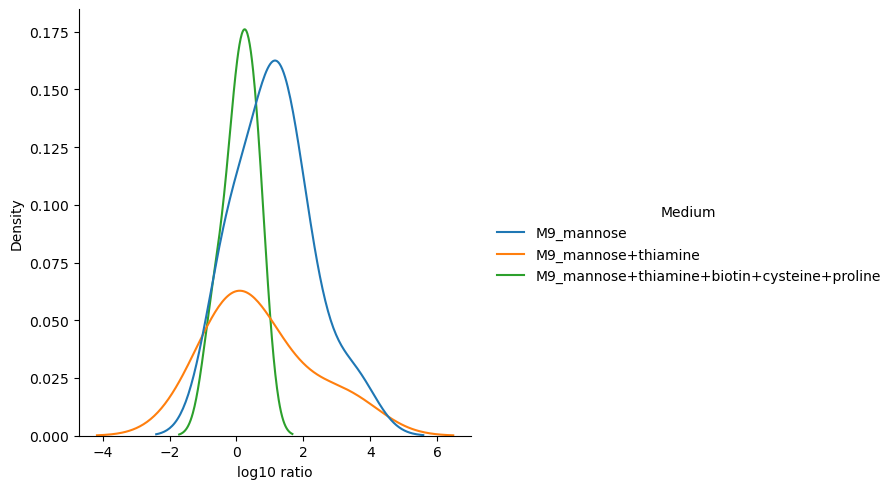

In [ ]:
ax = sns.displot(data = fresh_mannose_interactions, x = 'log10 ratio', hue = 'Medium', kind = 'kde')
# sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

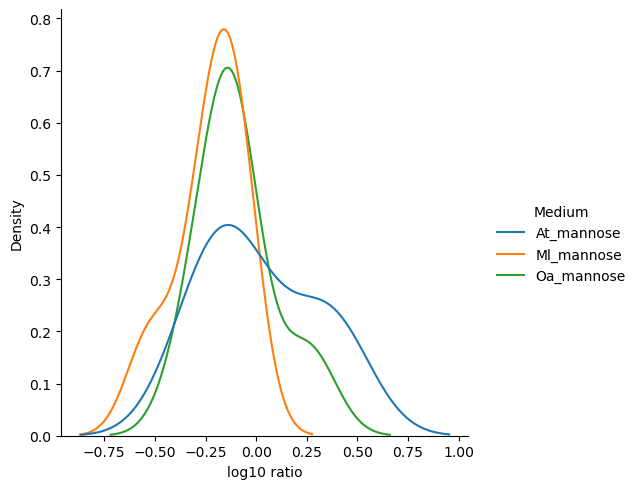

In [ ]:
ax = sns.displot(data = spent_mannose_interactions, x = 'log10 ratio', hue = 'Medium', kind = 'kde')
# sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

In [ ]:
all_interactions = pd.concat([fresh_mannose_interactions, spent_mannose_interactions]).reset_index()

In [ ]:
all_interactions['log10 pval'] = np.log10(all_interactions['T-test pvalue'])

<Axes: xlabel='log10 ratio', ylabel='Medium'>

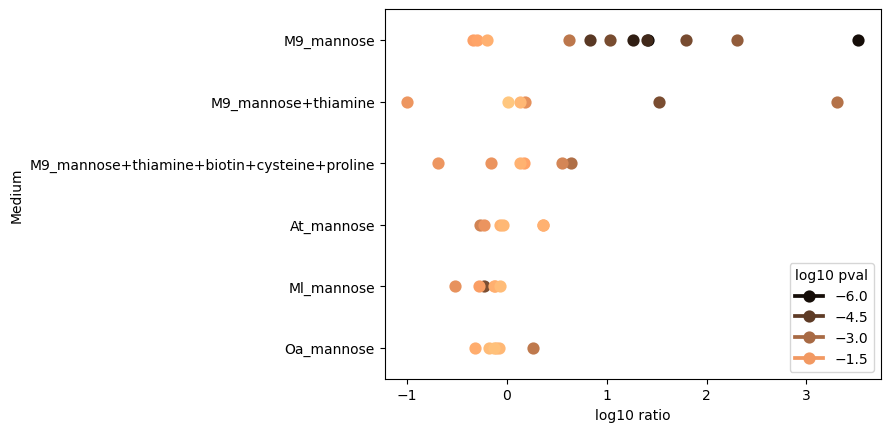

In [ ]:
sns.pointplot(data = all_interactions, x = 'log10 ratio', y = 'Medium', hue = 'log10 pval', palette='copper')

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_77193/3074553416.py:5: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


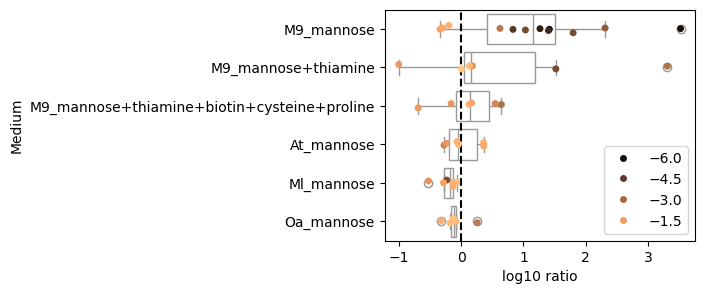

In [ ]:
fig, ax = plt.subplots(1, figsize = (4,3))
sns.stripplot(data = all_interactions, x = 'log10 ratio', y = 'Medium', hue = 'log10 pval', palette='copper', ax=ax)
sns.boxplot(data = all_interactions, x = 'log10 ratio', y = 'Medium', color = 'w')
ax.axvline(0, ls = '--', c = 'k', zorder = 2)
plt.tight_layout()
plt.savefig('Interactions mannose.pdf')

## Heatmaps

In [ ]:
all_interactions['Significance annot'] = ''
for i, row in all_interactions.iterrows():
    if 0.01 < row['T-test pvalue'] < 0.05:
        annot = '*'
    elif 0.001 < row['T-test pvalue'] < 0.01:
        annot = '**'
    elif row['T-test pvalue'] < 0.001:
        annot = '***'
    else:
        annot = ''
    all_interactions.at[i, 'Significance annot'] = annot
    

In [ ]:
all_interactions

,index,Focal species,Partner species,Medium,log10 ratio,log10 ratio std,T-test pvalue,log10 pval,Significance annot
0,0,At,Ct,M9_mannose,-0.197025,0.204718,1.629299e-01,-0.787999,
1,1,Ct,At,M9_mannose,1.796470,0.178920,9.824423e-05,-4.007693,***
2,2,At,Ml,M9_mannose,-0.338354,0.198920,5.356951e-02,-1.271082,
3,3,Ml,At,M9_mannose,3.518984,0.398043,1.043443e-06,-5.981531,***
4,4,At,Oa,M9_mannose,-0.299330,0.201307,7.041765e-02,-1.152318,
5,5,Oa,At,M9_mannose,1.414675,0.051844,3.746039e-07,-6.426428,***
6,6,Ct,Ml,M9_mannose,1.031340,0.175135,1.050370e-04,-3.978658,***
7,7,Ml,Ct,M9_mannose,0.831596,0.396524,2.506001e-05,-4.601019,***
8,8,Ct,Oa,M9_mannose,1.400884,0.163425,8.129531e-06,-5.089934,***
9,9,Oa,Ct,M9_mannose,1.264649,0.063461,3.589759e-06,-5.444935,***


M9_mannose
M9_mannose+thiamine
M9_mannose+thiamine+biotin+cysteine+proline
At_mannose
Ml_mannose
Oa_mannose


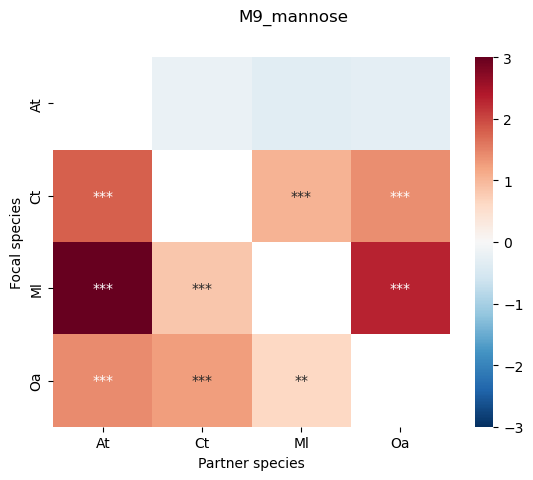

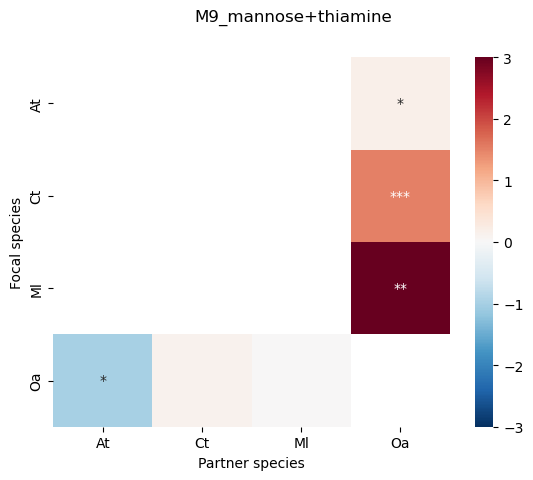

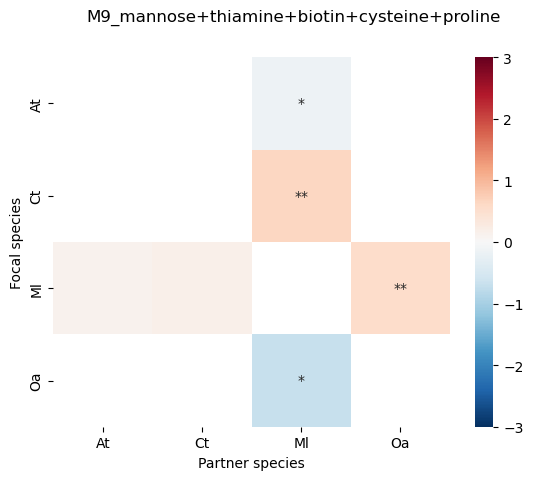

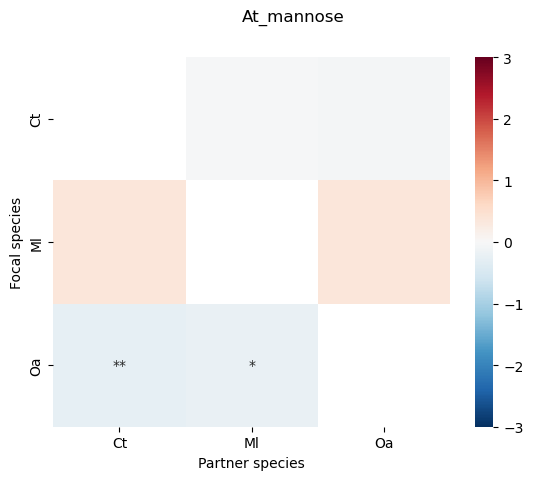

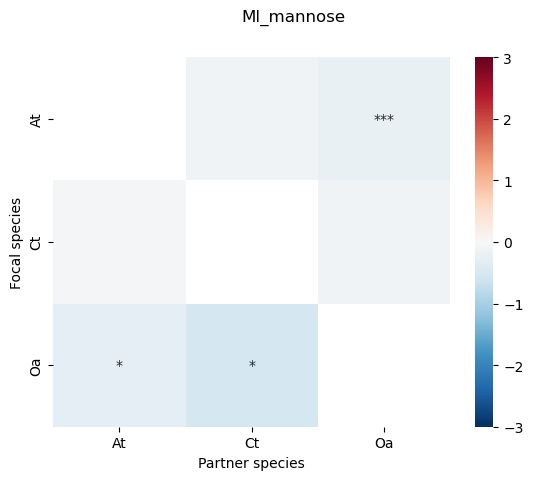

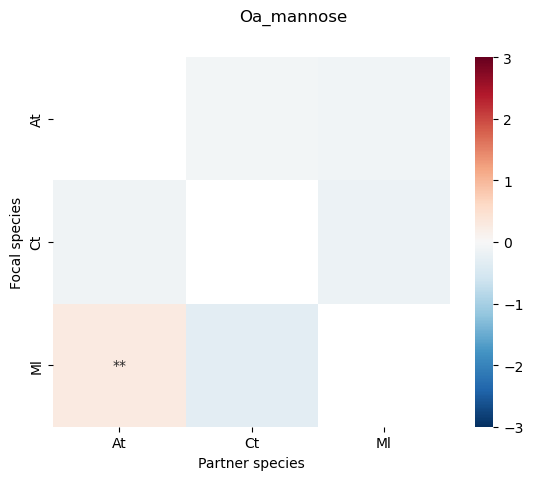

In [ ]:
for medium in all_interactions.Medium.unique():
    print(medium)
    dfm = all_interactions.loc[all_interactions.Medium==medium]
    dfmp = dfm.pivot(columns = 'Partner species', index = 'Focal species')
    fig, ax = plt.subplots(1)
    fig.suptitle(medium)
    sns.heatmap(dfmp['log10 ratio'], cmap = 'RdBu_r', ax = ax, vmin = -3, vmax = 3, annot = dfmp['Significance annot'], fmt = '')